In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from pathlib import Path

TARGET_CRS = "EPSG:5070"

In [5]:

folder = Path("./elections/candidate_totals_by_county")

IllinoisElectionResultsByCounty = {}

for file in folder.iterdir():
    IllinoisElectionResultsByCounty[file.name] = pd.read_csv(file)

In [12]:
folder = Path("./maps/raw/historical_districts_by_state/IL")

Illinois = {}

for file in folder.iterdir():
    Illinois[file.name] = gpd.read_file(file).to_crs(TARGET_CRS)

In [ ]:
ILTracts2020 = gpd.read_file('./maps/raw/historical_census_tracts_by_state/tracts_2022/Illinois_tl_2022_17_tract/tl_2022_17_tract.shp')
ILRoads2025 = gpd.read_file('./maps/raw/IL/tl_2025_17_prisecroads/tl_2025_17_prisecroads.shp').to_crs(TARGET_CRS)
ILPlaces2025 = gpd.read_file('./maps/raw/IL/tl_2025_17_place/tl_2025_17_place.shp').to_crs(TARGET_CRS)
ILTollways2025 = gpd.read_file("./maps/raw/IL/TollwayReferenceLines.gdb").to_crs(TARGET_CRS)
ILCounties = gpd.read_file("./maps/raw/historical_counties_by_state/IL_AtlasHCB/IL_Historical_Counties/IL_Historical_Counties.shp")

c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured MultiLineString' is converted to 'MultiLineString'
  return ogr_read(
c:\Users\Wayne\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'TollwayReferenceLines.gdb': 'NewReferenceLine' (default), 'ReferenceLine'. Specify layer parameter to avoid this warning.
  result = read_func(


In [43]:
ILCounties[['NAME', 'STATE', 'FIPS', "START_DATE", "END_DATE"]].to_csv("ILCountiesTestData.csv")

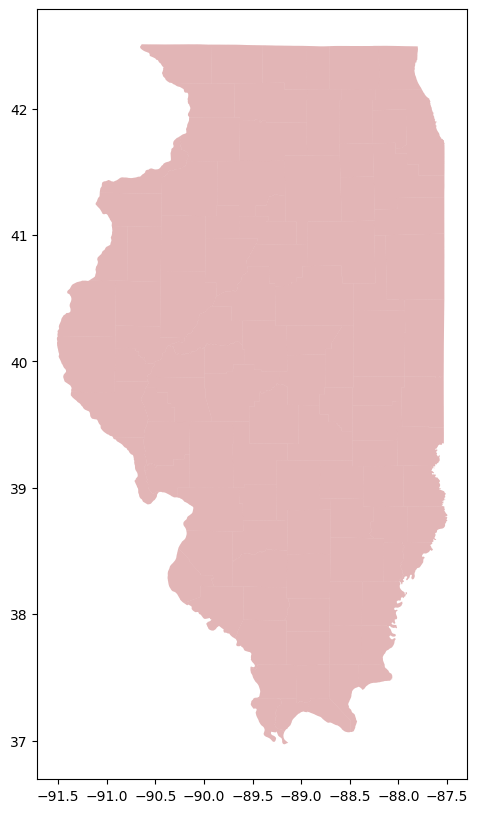

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

colors = {
    "I": "red",       # Interstate
    "U": "orange",    # US Highway
    "S": "gold",      # State
    "C": "green",     # County
    "M": "purple",    # Military
    "O": "gray",      # Other
}

# for rttyp, group in ILRoads2025.groupby("RTTYP"):

#     ILRoads2025.plot(
#         ax=ax,
#         edgecolor=colors[rttyp],
#         linewidth=0.5,
#         label="IL-8",
#     )

# ILTollways2025.plot(
#     ax=ax,
#     edgecolor='black',
#     linewidth=2,
#     label="IL-8",
# )

ILCounties[(
    (ILCounties['END_DATE'] == '2000-12-31')
)].plot(
    ax=ax,
    color='#a5141750',
    edgecolor='black'
    linewidth=1,
    label="IL-8", 
)

# plt.legend()
# plt.title("Precincts by Overlapping City")
plt.show()